In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Step 1 — Delay Distribution:

In [55]:
df = pd.read_csv("../data/processed/station_delays_imputed.csv")

In [56]:
df = df.sort_values(
    ["train_number", "journey_date", "station_sequence"]
)

df["target_destination_delay"] = (
    df.groupby(
        ["train_number", "journey_date"]
    )["arrival_delay_minutes"]
    .transform("last")
)

In [57]:
df = df[
    df["station_sequence"] !=
    df.groupby(
        ["train_number","journey_date"]
    )["station_sequence"].transform("max")
]

In [58]:
df["total_distance"] = (
    df.groupby(
        ["train_number", "journey_date"]
    )["distance_km"]
    .transform("max")
)

In [59]:
df["remaining_distance"] = (
    df["total_distance"] -
    df["distance_km"]
)

In [60]:
df["journey_completion"] = (
    df["distance_km"] /
    df["total_distance"]
)

In [61]:
df["prev_arrival_1"] = (
    df.groupby(
        ["train_number", "journey_date"]
    )["arrival_delay_minutes"]
    .shift(1)
)

df["prev_arrival_2"] = (
    df.groupby(
        ["train_number", "journey_date"]
    )["arrival_delay_minutes"]
    .shift(2)
)

In [62]:
df["prev_departure_1"] = (
    df.groupby(
        ["train_number", "journey_date"]
    )["departure_delay_minutes"]
    .shift(1)
)

df["prev_departure_2"] = (
    df.groupby(
        ["train_number", "journey_date"]
    )["departure_delay_minutes"]
    .shift(2)
)

In [63]:
lag_columns = [
    "prev_arrival_1",
    "prev_arrival_2",
    "prev_departure_1",
    "prev_departure_2"
]

df[lag_columns] = df[lag_columns].fillna(0)

In [64]:
df.head()

,journey_date,train_number,train_name,train_type,category,source_station,destination_station,station_sequence,station_code,station_name,...,arrival_delay_minutes,departure_delay_minutes,target_destination_delay,total_distance,remaining_distance,journey_completion,prev_arrival_1,prev_arrival_2,prev_departure_1,prev_departure_2
1,01-05-2026,12001,New Delhi Shatabdi Express,Shatabdi Express,Premium,RKMP,NDLS,2,BPL,Bhopal Junction,...,0.0,2.5,0.0,567.4,561.1,0.011103,0.0,0.0,0.0,0.0
2,01-05-2026,12001,New Delhi Shatabdi Express,Shatabdi Express,Premium,RKMP,NDLS,22,BINA,Bina Junction,...,0.0,5.0,0.0,567.4,422.5,0.255375,0.0,0.0,2.5,0.0
3,01-05-2026,12001,New Delhi Shatabdi Express,Shatabdi Express,Premium,RKMP,NDLS,29,LAR,Lalitpur Junction,...,10.0,16.0,0.0,567.4,359.8,0.365879,0.0,0.0,5.0,2.5
4,01-05-2026,12001,New Delhi Shatabdi Express,Shatabdi Express,Premium,RKMP,NDLS,43,VGLJ,VGL Jhansi Junction,...,8.0,16.0,0.0,567.4,269.4,0.525203,10.0,0.0,16.0,5.0
5,01-05-2026,12001,New Delhi Shatabdi Express,Shatabdi Express,Premium,RKMP,NDLS,55,GWL,Gwalior Junction,...,24.0,26.0,0.0,567.4,171.9,0.697039,8.0,10.0,16.0,16.0


In [91]:
df["journey_id"] = (
    df["train_number"].astype(str)
    + "_"
    + df["journey_date"].astype(str)
)

In [92]:
print(df.columns.tolist())

['journey_date', 'train_number', 'train_name', 'train_type', 'category', 'source_station', 'destination_station', 'station_sequence', 'station_code', 'station_name', 'distance_km', 'platform', 'status', 'scheduled_arrival', 'actual_arrival', 'scheduled_departure', 'actual_departure', 'arrival_delay_minutes', 'departure_delay_minutes', 'target_destination_delay', 'total_distance', 'remaining_distance', 'journey_completion', 'prev_arrival_1', 'prev_arrival_2', 'prev_departure_1', 'prev_departure_2', 'journey_id']


### Train Test Split

In [94]:
from sklearn.model_selection import GroupShuffleSplit

# Create Journey ID
df["journey_id"] = (
    df["train_number"].astype(str)
    + "_"
    + df["journey_date"].astype(str)
)

splitter = GroupShuffleSplit(
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        df,
        groups=df["journey_id"]
    )
)

In [95]:
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import pandas as pd
import numpy as np


TARGET = "target_destination_delay"


def run_experiment(feature_list, title):

    X = df[feature_list]
    y = df[TARGET]

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)

    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.4f}")

    importance = pd.DataFrame({
        "Feature": feature_list,
        "Importance": model.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )

    print("\nFeature Importance\n")
    print(importance)

    return model

In [96]:
full_features = [

    "arrival_delay_minutes",
    "departure_delay_minutes",

    "prev_arrival_1",
    "prev_arrival_2",
    "prev_departure_1",
    "prev_departure_2",

    "distance_km",
    "remaining_distance",
    "journey_completion",
    "station_sequence",
]

run_experiment(
    full_features,
    "Experiment 1 : Full Model"
)


Experiment 1 : Full Model
MAE : 27.33
RMSE: 65.24
R²  : 0.8515

Feature Importance

                   Feature  Importance
1  departure_delay_minutes    0.708137
7       remaining_distance    0.061324
8       journey_completion    0.052305
0    arrival_delay_minutes    0.040440
9         station_sequence    0.038023
2           prev_arrival_1    0.021931
5         prev_departure_2    0.021576
4         prev_departure_1    0.019723
3           prev_arrival_2    0.018884
6              distance_km    0.017658


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


### Experiment - 2

In [97]:
without_departure = [

    "arrival_delay_minutes",

    "prev_arrival_1",
    "prev_arrival_2",

    "prev_departure_1",
    "prev_departure_2",

    "distance_km",
    "remaining_distance",
    "journey_completion",
    "station_sequence",
]

run_experiment(
    without_departure,
    "Experiment 2 : Remove Departure Delay"
)


Experiment 2 : Remove Departure Delay
MAE : 28.41
RMSE: 67.22
R²  : 0.8423

Feature Importance

                 Feature  Importance
3       prev_departure_1    0.656421
0  arrival_delay_minutes    0.139499
6     remaining_distance    0.055232
7     journey_completion    0.046645
8       station_sequence    0.031639
4       prev_departure_2    0.020250
1         prev_arrival_1    0.017375
5            distance_km    0.016998
2         prev_arrival_2    0.015942


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


### Experiment - 3

In [98]:
only_current = [

    "arrival_delay_minutes",
    "departure_delay_minutes"

]

run_experiment(
    only_current,
    "Experiment 3 : Only Arrival + Departure"
)


Experiment 3 : Only Arrival + Departure
MAE : 30.33
RMSE: 61.15
R²  : 0.8695

Feature Importance

                   Feature  Importance
1  departure_delay_minutes    0.964274
0    arrival_delay_minutes    0.035726


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [99]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred
})

results["Error"] = results["Actual"] - results["Predicted"]
results["Absolute Error"] = results["Error"].abs()

results.sort_values(
    "Absolute Error",
    ascending=False
).head(20)

,Actual,Predicted,Error,Absolute Error
9972,1009.0,26.337572,982.662428,982.662428
10006,979.0,26.337572,952.662428,952.662428
7354,73.0,767.436584,-694.436584,694.436584
7397,67.0,757.596619,-690.596619,690.596619
10278,492.0,26.337572,465.662428,465.662428
7614,36.0,444.221130,-408.221130,408.221130
7402,67.0,444.221130,-377.221130,377.221130
8902,348.0,12.839893,335.160107,335.160107
8901,348.0,26.337572,321.662428,321.662428
7615,36.0,353.938690,-317.938690,317.938690


In [100]:
print(
    (df["target_destination_delay"] > 300).sum()
)

485


In [101]:
extreme = (
    df.groupby("journey_id")["target_destination_delay"]
      .first()
)

print((extreme > 300).sum())

15


### Train XGBoost Model

In [78]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [79]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²  :", r2_score(y_test, pred))

MAE : 27.334889037606374
RMSE: 65.2372604640105
R²  : 0.8514854117577109


In [80]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

                   Feature  Importance
1  departure_delay_minutes    0.708137
7       remaining_distance    0.061324
8       journey_completion    0.052305
0    arrival_delay_minutes    0.040440
9         station_sequence    0.038023
2           prev_arrival_1    0.021931
5         prev_departure_2    0.021576
4         prev_departure_1    0.019723
3           prev_arrival_2    0.018884
6              distance_km    0.017658


### Experiment - 2

In [83]:
features = [
    "arrival_delay_minutes",
    "prev_arrival_1",
    "prev_arrival_2",
    "prev_departure_1",
    "prev_departure_2",
    "distance_km",
    "remaining_distance",
    "journey_completion",
    "station_sequence",
]

In [84]:
target = "target_destination_delay"

In [85]:
X = df[features]
y = df[target]

In [86]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X,
        y,
        groups=df["journey_id"]
    )
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [87]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [88]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²  :", r2_score(y_test, pred))

MAE : 28.40911459353176
RMSE: 67.22345852521822
R²  : 0.842304467582352


In [89]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

                 Feature  Importance
3       prev_departure_1    0.656421
0  arrival_delay_minutes    0.139499
6     remaining_distance    0.055232
7     journey_completion    0.046645
8       station_sequence    0.031639
4       prev_departure_2    0.020250
1         prev_arrival_1    0.017375
5            distance_km    0.016998
2         prev_arrival_2    0.015942


### Experiment - 3

In [90]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

# ====================================
# Features & Target
# ====================================

features = [
    "arrival_delay_minutes",
    "departure_delay_minutes",
]

target = "target_destination_delay"

X = df[features]
y = df[target]

# ====================================
# Group-wise Train/Test Split
# ====================================

df["journey_id"] = (
    df["train_number"].astype(str)
    + "_"
    + df["journey_date"].astype(str)
)

splitter = GroupShuffleSplit(
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X,
        y,
        groups=df["journey_id"]
    )
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# ====================================
# Train Model
# ====================================

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
)

model.fit(X_train, y_train)

# ====================================
# Predictions
# ====================================

pred = model.predict(X_test)

# ====================================
# Evaluation
# ====================================

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

# ====================================
# Feature Importance
# ====================================

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)

MAE : 30.33
RMSE: 61.15
R²  : 0.8695

Feature Importance:
                   Feature  Importance
1  departure_delay_minutes    0.964274
0    arrival_delay_minutes    0.035726


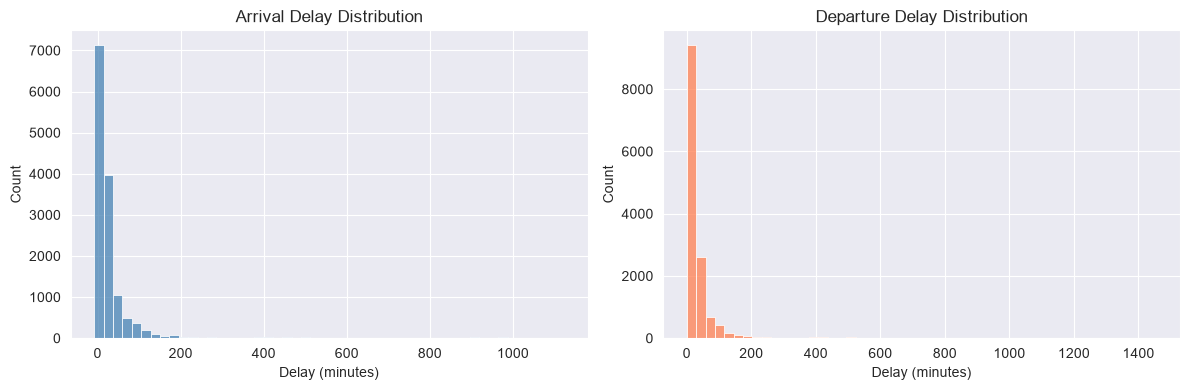

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['arrival_delay_minutes'], bins=50, color='steelblue')
plt.title('Arrival Delay Distribution')
plt.xlabel('Delay (minutes)')

plt.subplot(1, 2, 2)
sns.histplot(df['departure_delay_minutes'], bins=50, color='coral')
plt.title('Departure Delay Distribution')
plt.xlabel('Delay (minutes)')

plt.tight_layout()
plt.show()

In [19]:
df["departure_delay_minutes"].describe(
    percentiles=[0.5,0.75,0.9,0.95,0.99,0.995]
)

count    13844.000000
mean        43.033083
std        112.536020
min          0.000000
50%         19.000000
75%         36.000000
90%         76.000000
95%        120.000000
99%        729.094286
99.5%      985.785000
max       1456.000000
Name: departure_delay_minutes, dtype: float64

In [20]:
df["arrival_delay_minutes"].describe(
    percentiles=[0.5,0.75,0.9,0.95,0.99,0.995]
)

count    13844.000000
mean        38.514627
std        109.440101
min         -8.000000
50%         14.000000
75%         31.000000
90%         73.000000
95%        118.000000
99%        666.508000
99.5%      971.000000
max       1123.000000
Name: arrival_delay_minutes, dtype: float64

In [21]:
df[
    ["arrival_delay_minutes",
     "departure_delay_minutes"]
].corr()

,arrival_delay_minutes,departure_delay_minutes
arrival_delay_minutes,1.000000,0.944329
departure_delay_minutes,0.944329,1.000000


## Training a Baseline Model

In [22]:
# Sort first
df = df.sort_values(['train_number', 'journey_date', 'station_sequence'])

# Next station arrival delay
df['target_delay'] = df.groupby(['train_number', 'journey_date'])['arrival_delay_minutes'].shift(-1)

print(df['target_delay'].isnull().sum())
df.head()

df = df.dropna(subset=['target_delay'])
print(f"Rows after dropping: {len(df)}")
print(f"NaN in target_delay: {df['target_delay'].isnull().sum()}")

797
Rows after dropping: 13047
NaN in target_delay: 0


In [23]:
FEATURES = [
    'arrival_delay_minutes',
    'departure_delay_minutes',
    'station_sequence',
    'distance_km'
]

TARGET = 'target_delay'

X = df[FEATURES]
y = df[TARGET]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (13047, 4)
y shape: (13047,)


In [24]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")

Train:      (10437, 4)
Validation: (1305, 4)
Test:       (1305, 4)


In [25]:
from xgboost import XGBRegressor

model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("✅ Model trained!")

✅ Model trained!


In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 7.93
RMSE : 15.62
R²   : 0.9841


In [27]:
df[['arrival_delay_minutes', 'departure_delay_minutes', 'target_delay']].corr()

,arrival_delay_minutes,departure_delay_minutes,target_delay
arrival_delay_minutes,1.000000,0.970765,0.978076
departure_delay_minutes,0.970765,1.000000,0.956687
target_delay,0.978076,0.956687,1.000000


### Feature Importance

In [28]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

                   Feature  Importance
0    arrival_delay_minutes    0.840180
1  departure_delay_minutes    0.147065
3              distance_km    0.006734
2         station_sequence    0.006022


In [29]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

baseline_pred = X_test["arrival_delay_minutes"]

mae = mean_absolute_error(y_test, baseline_pred)
rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
r2 = r2_score(y_test, baseline_pred)

print(f"Baseline MAE : {mae:.2f}")
print(f"Baseline RMSE: {rmse:.2f}")
print(f"Baseline R²  : {r2:.4f}")

Baseline MAE : 11.85
Baseline RMSE: 19.69
Baseline R²  : 0.9747


In [30]:
results = X_test.copy()

results["actual"] = y_test.values
results["predicted"] = pred
results["error"] = results["actual"] - results["predicted"]
results["abs_error"] = results["error"].abs()

results = results.sort_values(
    "abs_error",
    ascending=False
)

results.head(20)

,arrival_delay_minutes,departure_delay_minutes,station_sequence,distance_km,actual,predicted,error,abs_error
8677,578.000000,589.000000,149,1106.2,613.000000,844.551331,-231.551331,231.551331
3493,0.000000,13.000000,147,881.0,239.000000,18.123360,220.876640,220.876640
13088,212.000000,224.000000,61,409.9,405.000000,222.556427,182.443573,182.443573
3058,132.000000,5.000000,343,2437.8,123.000000,15.374081,107.625919,107.625919
12199,314.000000,365.000000,189,1264.6,475.000000,367.750000,107.250000,107.250000
4402,14.000000,31.000000,144,821.2,103.000000,24.913235,78.086765,78.086765
8745,820.692308,1046.461538,138,1019.7,887.846154,813.475525,74.370629,74.370629
8758,1123.000000,1127.000000,307,2249.5,1096.000000,1021.637451,74.362549,74.362549
10025,987.000000,990.000000,256,1821.7,955.000000,1024.901489,-69.901489,69.901489
3377,25.000000,46.000000,180,1089.4,89.000000,27.558651,61.441349,61.441349
